In [1]:
import pandas as pd

def classify_loops(loops_path, tads_path, output_path):
    """
    Classify loops based on their position relative to TADs and save the results.
    
    Args:
        loops_path (str): Path to loops BED file
        tads_path (str): Path to TAD boundaries BED file
        output_path (str): Output file path for classified loops
    """
    # Load data
    loops_df = pd.read_csv(
        loops_path, 
        sep="\t", 
        header=None, 
        names=["chr1", "start1", "end1", "chr2", "start2", "end2", "element"]
    )
    tads_df = pd.read_csv(
        tads_path, 
        sep="\t", 
        header=None, 
        names=["chr", "start", "end"]
    )
    
    # Preprocess TADs: create nested dictionary {chrom: {TAD_index: [start, end]}}
    chrom_tads = {}
    for _, row in tads_df.iterrows():
        chrom = row['chr']
        if chrom not in chrom_tads:
            chrom_tads[chrom] = {}
        chrom_tads[chrom][len(chrom_tads[chrom])] = [row['start'], row['end']]
    
    # Find TAD containing a genomic position
    def find_tad(chrom, pos):
        if chrom not in chrom_tads:
            return None
        for tad_idx, (start, end) in chrom_tads[chrom].items():
            if start <= pos <= end:
                return tad_idx
        return None
    
    # Classify each loop
    classifications = []
    for _, row in loops_df.iterrows():
        chr1, chr2 = row['chr1'], row['chr2']
        pos1, pos2 = row['start1'], row['start2']
        
        # Inter-chromosomal loop
        if chr1 != chr2:
            classifications.append("Inter-chromosomal")
            continue
            
        # Intra-chromosomal loop
        tad1 = find_tad(chr1, pos1)
        tad2 = find_tad(chr2, pos2)
        
        if tad1 is None or tad2 is None:
            classifications.append("Unclassified")
        elif tad1 == tad2:
            classifications.append("Within One TAD")
        elif abs(tad1 - tad2) == 1:
            classifications.append("Adjacent TADs")
        else:
            classifications.append("Distant TADs")
    
    loops_df['classification'] = classifications
    loops_df.to_csv(output_path, sep='\t', index=False, header=False)


In [3]:
# File configurations
configs = [
    {
        'loop_type': 'up',
        'condition': 'old_WT',
        'loops_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/up_old_WT_union.bed",
        'tads_path': "/tank/projects/kashuk_sirt6_hic/boundaries_10k/old_50kb_boundaries.bed",
        'output_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/up_old_WT_classified.bed"
    },
    {
        'loop_type': 'down',
        'condition': 'old_WT',
        'loops_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/down_old_WT_union.bed",
        'tads_path': "/tank/projects/kashuk_sirt6_hic/boundaries_10k/old_50kb_boundaries.bed",
        'output_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/down_old_WT_classified.bed"
    },
    {
        'loop_type': 'up',
        'condition': 'KO_WT',
        'loops_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/up_KO_WT_union.bed",
        'tads_path': "/tank/projects/kashuk_sirt6_hic/boundaries_10k/KO_50kb_boundaries.bed",  
        'output_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/up_KO_WT_classified.bed"
    },
    {
        'loop_type': 'down',
        'condition': 'KO_WT',
        'loops_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/down_KO_WT_union.bed",
        'tads_path': "/tank/projects/kashuk_sirt6_hic/boundaries_10k/KO_50kb_boundaries.bed",  
        'output_path': "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/down_KO_WT_classified.bed"
    }
]


for conf in configs:
    print(f"Processing {conf['loop_type']} loops for {conf['condition']}...")
    classify_loops(conf['loops_path'], conf['tads_path'], conf['output_path'])
    print(f"Saved results to {conf['output_path']}\n")

Processing up loops for old_WT...
Saved results to /tank/projects/kashuk_sirt6_hic/loops_10k/diff/up_old_WT_classified.bed

Processing down loops for old_WT...
Saved results to /tank/projects/kashuk_sirt6_hic/loops_10k/diff/down_old_WT_classified.bed

Processing up loops for KO_WT...
Saved results to /tank/projects/kashuk_sirt6_hic/loops_10k/diff/up_KO_WT_classified.bed

Processing down loops for KO_WT...
Saved results to /tank/projects/kashuk_sirt6_hic/loops_10k/diff/down_KO_WT_classified.bed



In [4]:
%load_ext rpy2.ipython


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    ── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In addition: Warning messages:
1: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
  library ‘/usr/lib/R/site-library’ contains no packages
2: The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


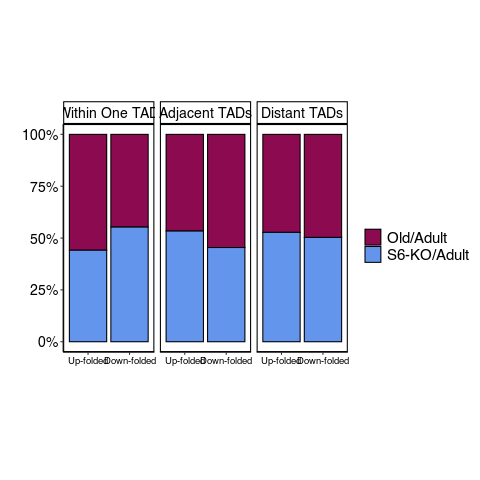

In [5]:
%%R

library(reticulate)
library(tidyverse)

library(reticulate)
library(tidyverse)

up_old <- read.table(
  "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/up_old_WT_classified.bed",
  sep = "\t",
  header = FALSE,
  col.names = c("chr1", "start1", "end1", "chr2", "start2", "end2", "element", "classification")
)

down_old <- read.table(
  "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/down_old_WT_classified.bed",
  sep = "\t",
  header = FALSE,
  col.names = c("chr1", "start1", "end1", "chr2", "start2", "end2", "element", "classification")
)

up_ko <- read.table(
  "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/up_KO_WT_classified.bed",
  sep = "\t",
  header = FALSE,
  col.names = c("chr1", "start1", "end1", "chr2", "start2", "end2", "element", "classification")
)

down_ko <- read.table(
  "/tank/projects/kashuk_sirt6_hic/loops_10k/diff/down_KO_WT_classified.bed",
  sep = "\t",
  header = FALSE,
  col.names = c("chr1", "start1", "end1", "chr2", "start2", "end2", "element", "classification")
)

classification <- c(
  up_old$classification,
  down_old$classification,
  up_ko$classification,
  down_ko$classification
)

type <- c(
  rep("Up-folded", times = nrow(up_old)),
  rep("Down-folded", times = nrow(down_old)),
  rep("Up-folded", times = nrow(up_ko)),
  rep("Down-folded", times = nrow(down_ko))
)

Type <- c(
  rep("Old/Adult", times = nrow(up_old) + nrow(down_old)),
  rep("S6-KO/Adult", times = nrow(up_ko) + nrow(down_ko))
)

df <- data.frame(classification, type, Type)

df$type <- factor(df$type, levels=c('Up-folded', 'Down-folded'))
df$Type <- factor(df$Type, levels=c('Old/Adult', 'S6-KO/Adult'))
df$classification <- factor(df$classification, levels=c('Within One TAD', 'Adjacent TADs', 'Distant TADs'))


df_summary <- df %>%
  group_by(classification, type, Type) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(type, classification) %>%  
  mutate(total = sum(count),  
         percentage = (count / total) * 100) %>%
  ungroup()

ggplot(df_summary, aes(x = type, y = percentage, fill = Type)) +
  geom_bar(stat = "identity", position = "stack", color='black') +
  facet_wrap(~ classification) +
  theme_classic() +
  labs(
       x = "",
       y = "",
       fill = "") +
  scale_y_continuous(labels = scales::percent_format(scale = 1)) +
  scale_fill_manual(values=c('deeppink4','cornflowerblue')) +
  theme(
    axis.text.x = element_text(color='black', size=9.5),
    axis.text.y = element_text(size = 14, color = "black"),
    axis.title.y = element_text(size = 14, color = "black"),
    panel.grid.minor = element_blank(),
    axis.line = element_line(colour = "black"),
    panel.border = element_rect(colour = "black", fill = NA, size = 1),
    strip.text = element_text(size = 14, color = "black"),
    aspect.ratio = 2.5/1,
    legend.text = element_text(color = 'black', size=15)
    #legend.position = "none"
  )